In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

warnings.filterwarnings("ignore")

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models

In [3]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    jaccard_score,
    confusion_matrix
)

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : Tesla T4


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
DATASET_DIR = "/content/drive/MyDrive/Mammogram_Shape_Preprocess"

In [8]:
print(os.listdir(DATASET_DIR))

['processed_images', 'processed_masks', 'boxed_images', 'roi_images', 'roi_masks', 'NEW_ROI_X.npy', 'NEW_ROI_Y.npy', 'X.npy', 'Y.npy', 'shape_labels.npy', 'X_train.npy', 'Y_train.npy', 'shape_train.npy', 'X_val.npy', 'Y_val.npy', 'shape_val.npy', 'X_test.npy', 'Y_test.npy', 'shape_test.npy', 'NEW_ROI_X_train.npy', 'NEW_ROI_Y_train.npy', 'roi_shape_train.npy', 'NEW_ROI_X_val.npy', 'NEW_ROI_Y_val.npy', 'roi_shape_val.npy', 'NEW_ROI_X_test.npy', 'NEW_ROI_Y_test.npy', 'roi_shape_test.npy', 'best_maskrcnn.pth', 'best_maskrcnn_v2.pth', 'SwinUNet_BCEDice_final_best.pth', 'YOLO_dataset', 'RetinaUNet_Results']


In [9]:
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 1
NUM_WORKERS = 2
PIN_MEMORY = True

In [10]:
print(f"Image Size     : {IMG_SIZE}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Epochs         : {EPOCHS}")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Device         : {device}")

Image Size     : 128
Batch Size     : 16
Epochs         : 50
Learning Rate  : 0.0001
Device         : cuda


In [11]:
X_train = np.load(os.path.join(DATASET_DIR, "NEW_ROI_X_train.npy"))
X_val   = np.load(os.path.join(DATASET_DIR, "NEW_ROI_X_val.npy"))
X_test  = np.load(os.path.join(DATASET_DIR, "NEW_ROI_X_test.npy"))

Y_train = np.load(os.path.join(DATASET_DIR, "NEW_ROI_Y_train.npy"))
Y_val   = np.load(os.path.join(DATASET_DIR, "NEW_ROI_Y_val.npy"))
Y_test  = np.load(os.path.join(DATASET_DIR, "NEW_ROI_Y_test.npy"))

shape_train = np.load(
    os.path.join(DATASET_DIR, "roi_shape_train.npy"),
    allow_pickle=True
)

shape_val = np.load(
    os.path.join(DATASET_DIR, "roi_shape_val.npy"),
    allow_pickle=True
)

shape_test = np.load(
    os.path.join(DATASET_DIR, "roi_shape_test.npy"),
    allow_pickle=True
)

In [12]:
print("Training Images :", X_train.shape)
print("Training Masks  :", Y_train.shape)
print("Training Shapes :", shape_train.shape)

print()

print("Validation Images :", X_val.shape)
print("Validation Masks  :", Y_val.shape)
print("Validation Shapes :", shape_val.shape)

print()

print("Testing Images :", X_test.shape)
print("Testing Masks  :", Y_test.shape)
print("Testing Shapes :", shape_test.shape)

Training Images : (1004, 128, 128, 1)
Training Masks  : (1004, 128, 128, 1)
Training Shapes : (1004,)

Validation Images : (126, 128, 128, 1)
Validation Masks  : (126, 128, 128, 1)
Validation Shapes : (126,)

Testing Images : (130, 128, 128, 1)
Testing Masks  : (130, 128, 128, 1)
Testing Shapes : (130,)


In [13]:
print("Image dtype :", X_train.dtype)
print("Mask dtype  :", Y_train.dtype)
print("Shape dtype :", shape_train.dtype)

Image dtype : float32
Mask dtype  : uint8
Shape dtype : int64


In [14]:
print("Image Min :", X_train.min())
print("Image Max :", X_train.max())

print()

print("Mask Min :", Y_train.min())
print("Mask Max :", Y_train.max())

print()

print("Unique Mask Values")

print(np.unique(Y_train))

Image Min : 0.003921569
Image Max : 1.0

Mask Min : 0
Mask Max : 1

Unique Mask Values
[0 1]


In [15]:
print("Unique Shape Labels")

print(np.unique(shape_train))

Unique Shape Labels
[0 1 2]


In [16]:
shape_df = pd.DataFrame(shape_train, columns=["Shape"])

distribution = (
    shape_df["Shape"]
    .value_counts()
    .sort_index()
)

print(distribution)

Shape
0    363
1    322
2    319
Name: count, dtype: int64


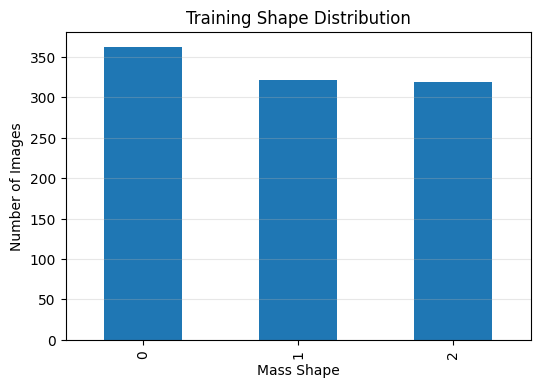

In [17]:
plt.figure(figsize=(6,4))

distribution.plot(kind="bar")

plt.title("Training Shape Distribution")

plt.xlabel("Mass Shape")

plt.ylabel("Number of Images")

plt.grid(axis="y", alpha=0.3)

plt.show()

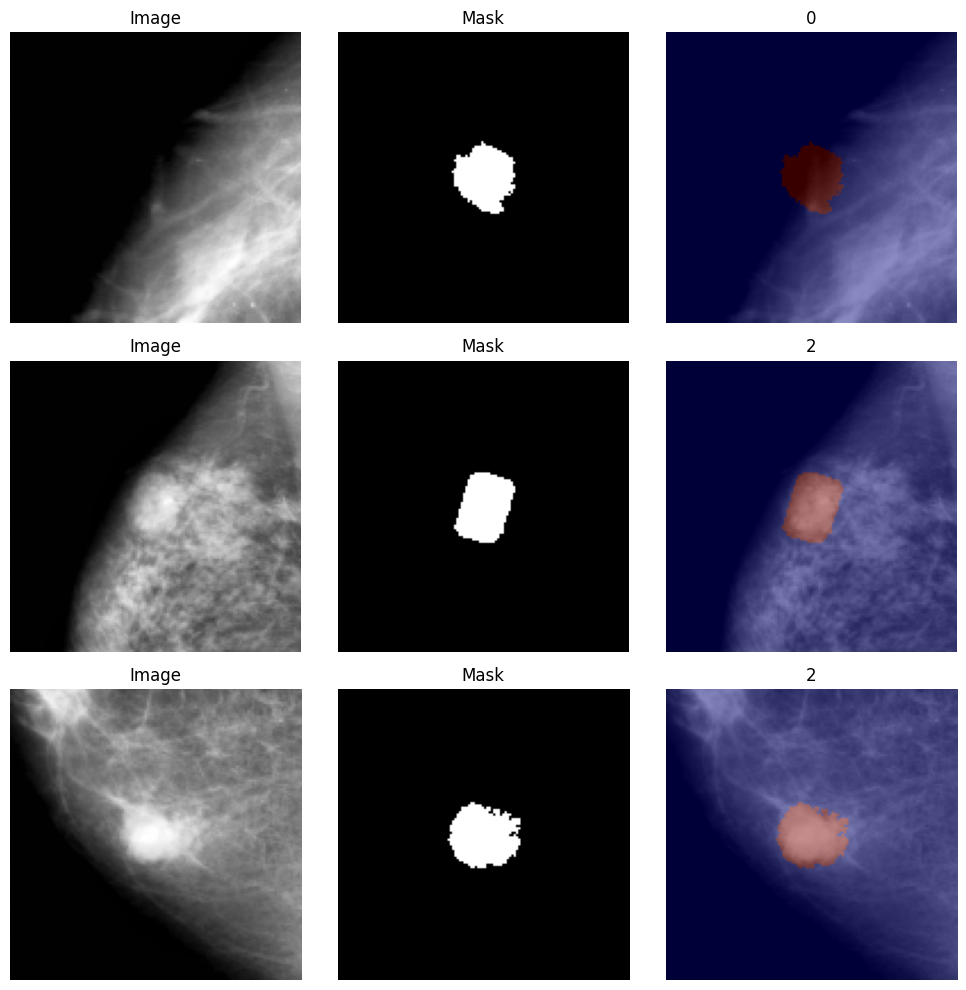

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))

indices = np.random.choice(len(X_train), 3, replace=False)

for row, idx in enumerate(indices):

    image = X_train[idx].squeeze()
    mask = Y_train[idx].squeeze()
    shape = shape_train[idx]

    axes[row,0].imshow(image, cmap="gray")
    axes[row,0].set_title("Image")

    axes[row,1].imshow(mask, cmap="gray")
    axes[row,1].set_title("Mask")

    axes[row,2].imshow(image, cmap="gray")
    axes[row,2].imshow(mask, cmap="jet", alpha=0.45)
    axes[row,2].set_title(f"{shape}")

    for col in range(3):
        axes[row,col].axis("off")

plt.tight_layout()

plt.show()

In [19]:
assert len(X_train) == len(Y_train) == len(shape_train)
assert len(X_val) == len(Y_val) == len(shape_val)
assert len(X_test) == len(Y_test) == len(shape_test)

In [20]:
summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(X_train), len(X_val), len(X_test)],
    "Masks": [len(Y_train), len(Y_val), len(Y_test)],
    "Shape Labels": [len(shape_train), len(shape_val), len(shape_test)]
})

summary

,Split,Images,Masks,Shape Labels
0,Train,1004,1004,1004
1,Validation,126,126,126
2,Test,130,130,130


In [21]:
SHAPE_MAP = {
    0: "Irregular",
    1: "Oval",
    2: "Lobulated"
}

print(SHAPE_MAP)

{0: 'Irregular', 1: 'Oval', 2: 'Lobulated'}


In [22]:
class MammographyDataset(Dataset):

    def __init__(self, images, masks, shapes):
        self.images = images
        self.masks = masks
        self.shapes = shapes

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        ).permute(2, 0, 1)

        shape = torch.tensor(
            self.shapes[idx],
            dtype=torch.long
        )

        return image, mask, shape

In [23]:
train_dataset = MammographyDataset(
    X_train,
    Y_train,
    shape_train
)

val_dataset = MammographyDataset(
    X_val,
    Y_val,
    shape_val
)

test_dataset = MammographyDataset(
    X_test,
    Y_test,
    shape_test
)

In [24]:
print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(val_dataset))
print("Testing Samples    :", len(test_dataset))

Training Samples   : 1004
Validation Samples : 126
Testing Samples    : 130


In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [26]:
images, masks, shapes = next(iter(train_loader))

print("Images :", images.shape)
print("Masks  :", masks.shape)
print("Shapes :", shapes.shape)

Images : torch.Size([16, 1, 128, 128])
Masks  : torch.Size([16, 1, 128, 128])
Shapes : torch.Size([16])


In [27]:
print("Image dtype :", images.dtype)
print("Mask dtype  :", masks.dtype)
print("Shape dtype :", shapes.dtype)

Image dtype : torch.float32
Mask dtype  : torch.float32
Shape dtype : torch.int64


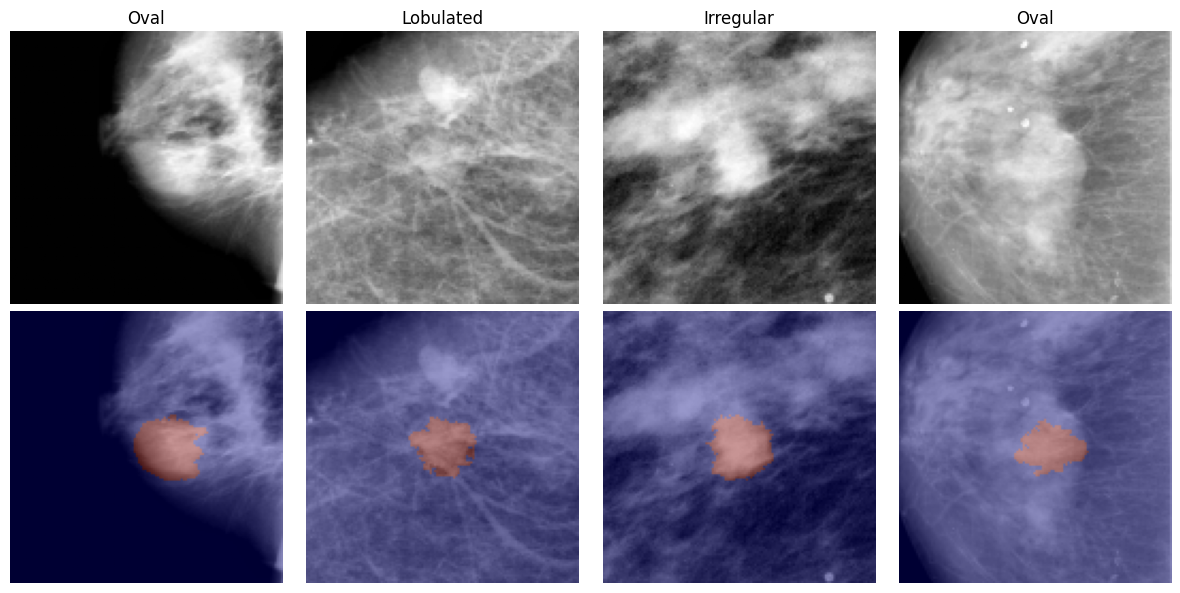

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):

    img = images[i].squeeze().numpy()
    mask = masks[i].squeeze().numpy()
    label = SHAPE_MAP[shapes[i].item()]

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(label)
    axes[0, i].axis("off")

    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].imshow(mask, cmap="jet", alpha=0.4)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [29]:
train_steps = len(train_loader)
val_steps = len(val_loader)
test_steps = len(test_loader)

print("Train Steps :", train_steps)
print("Validation Steps :", val_steps)
print("Test Steps :", test_steps)

Train Steps : 63
Validation Steps : 8
Test Steps : 9


In [30]:
!pip install -q segmentation-models-pytorch
!pip install -q ttach

In [31]:
import segmentation_models_pytorch as smp
import ttach as tta

In [32]:
model = smp.FPN(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=1,

    classes=1,

    activation=None,

    decoder_dropout=0.2,

    decoder_merge_policy="add"

).to(device)

In [33]:
print(model)

FPN(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [34]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 23,149,121
Trainable Parameters : 23,149,121


In [35]:
dummy = torch.randn(
    2,
    1,
    128,
    128
).to(device)

with torch.no_grad():

    output = model(dummy)

print("Input Shape :", dummy.shape)
print("Output Shape:", output.shape)

Input Shape : torch.Size([2, 1, 128, 128])
Output Shape: torch.Size([2, 1, 128, 128])


In [36]:
print(output.min().item())
print(output.max().item())

-4.116764068603516
7.106452941894531


In [37]:
print("Architecture : FPN")
print("Encoder      : ResNet34")
print("Pretrained   : ImageNet")
print("Input Size   :", IMG_SIZE)
print("Output       : Binary Segmentation")
print("Classes      : 1")

Architecture : FPN
Encoder      : ResNet34
Pretrained   : ImageNet
Input Size   : 128
Output       : Binary Segmentation
Classes      : 1


In [38]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

In [39]:
class BCEDiceLoss(nn.Module):

    def __init__(self,
                 bce_weight=0.5,
                 dice_weight=0.5):

        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()

        self.dice = DiceLoss()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)

        dice_loss = self.dice(logits, targets)

        loss = (
            self.bce_weight * bce_loss +
            self.dice_weight * dice_loss
        )

        return loss

In [40]:
criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

In [41]:
dummy_pred = torch.randn(
    2,
    1,
    128,
    128
).to(device)

dummy_mask = torch.randint(
    0,
    2,
    (2, 1, 128, 128)
).float().to(device)

loss = criterion(
    dummy_pred,
    dummy_mask
)

print("Loss :", loss.item())

Loss : 0.6529468297958374


In [42]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    jaccard_score,
    confusion_matrix
)

In [43]:
def calculate_metrics(logits, masks, threshold=0.5):

    # Convert logits → probabilities
    probs = torch.sigmoid(logits)

    # Binary prediction
    preds = (probs > threshold).float()

    # Flatten
    preds = preds.cpu().numpy().astype(np.uint8).flatten()
    masks = masks.cpu().numpy().astype(np.uint8).flatten()

    # Dice
    intersection = np.sum(preds * masks)

    dice = (
        (2 * intersection + 1e-6)
        /
        (preds.sum() + masks.sum() + 1e-6)
    )

    # IoU
    iou = jaccard_score(
        masks,
        preds,
        zero_division=0
    )

    # Precision
    precision = precision_score(
        masks,
        preds,
        zero_division=0
    )

    # Recall
    recall = recall_score(
        masks,
        preds,
        zero_division=0
    )

    # F1
    f1 = f1_score(
        masks,
        preds,
        zero_division=0
    )

    # Accuracy
    accuracy = accuracy_score(
        masks,
        preds
    )

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        masks,
        preds,
        labels=[0,1]
    ).ravel()

    # Specificity
    specificity = tn / (tn + fp + 1e-6)

    return {
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "specificity": specificity
    }

In [44]:
dummy_logits = torch.randn(
    2,
    1,
    128,
    128
).to(device)

dummy_masks = torch.randint(
    0,
    2,
    (2,1,128,128)
).float().to(device)

metrics = calculate_metrics(
    dummy_logits,
    dummy_masks
)

for key, value in metrics.items():
    print(f"{key:12s}: {value:.4f}")

dice        : 0.4877
iou         : 0.3225
precision   : 0.4878
recall      : 0.4876
f1          : 0.4877
accuracy    : 0.4938
specificity : 0.4998


In [45]:
def print_metrics(metrics):

    print(f"Dice Score : {metrics['dice']:.4f}")
    print(f"IoU        : {metrics['iou']:.4f}")
    print(f"Precision  : {metrics['precision']:.4f}")
    print(f"Recall     : {metrics['recall']:.4f}")
    print(f"F1 Score   : {metrics['f1']:.4f}")
    print(f"Accuracy   : {metrics['accuracy']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")

In [46]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [47]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

In [48]:
from torch.amp import GradScaler, autocast

scaler = GradScaler(device="cuda")

In [49]:
class EarlyStopping:

    def __init__(self,
                 patience=10,
                 delta=0.0):

        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")

        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f"EarlyStopping Counter: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

In [50]:
early_stopping = EarlyStopping(
    patience=10,
    delta=0.0001
)

In [57]:
BEST_MODEL_PATH = "best_fpn_model.pth"

best_val_loss = float("inf")
best_val_dice = 0.0

In [52]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": [],

    "learning_rate": []

}

In [53]:
print("Optimizer :", optimizer.__class__.__name__)
print("Scheduler :", scheduler.__class__.__name__)
print("AMP Enabled :", torch.cuda.is_available())
print("Early Stopping :", early_stopping.patience)
print("Checkpoint :", BEST_MODEL_PATH)

Optimizer : AdamW
Scheduler : CosineAnnealingLR
AMP Enabled : True
Early Stopping : 10
Checkpoint : best_fpn_model.pth


In [54]:
def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    scaler,
                    device):

    model.train()

    running_loss = 0

    metric_sum = {
        "dice":0,
        "iou":0,
        "precision":0,
        "recall":0,
        "f1":0,
        "accuracy":0,
        "specificity":0
    }

    for images, masks, _ in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        metrics = calculate_metrics(outputs.detach(), masks)

        for key in metric_sum:
            metric_sum[key] += metrics[key]

    epoch_loss = running_loss / len(loader)

    for key in metric_sum:
        metric_sum[key] /= len(loader)

    return epoch_loss, metric_sum

In [55]:
def validate_one_epoch(model,
                       loader,
                       criterion,
                       device):

    model.eval()

    running_loss = 0

    metric_sum = {
        "dice":0,
        "iou":0,
        "precision":0,
        "recall":0,
        "f1":0,
        "accuracy":0,
        "specificity":0
    }

    with torch.no_grad():

        for images, masks, _ in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_loss += loss.item()

            metrics = calculate_metrics(outputs, masks)

            for key in metric_sum:
                metric_sum[key] += metrics[key]

    epoch_loss = running_loss / len(loader)

    for key in metric_sum:
        metric_sum[key] /= len(loader)

    return epoch_loss, metric_sum

In [59]:
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        device
    )

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_metrics["dice"])

    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_metrics["iou"])

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    if val_metrics["dice"] > best_val_dice:

        best_val_dice = val_metrics["dice"]
        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"Best model saved! "
            f"Validation Dice: {best_val_dice:.4f}"
        )

    early_stopping(val_loss)

    print("-"*70)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}]"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Validation Loss : {val_loss:.4f}"
    )

    print()

    print("Training Metrics")

    print_metrics(train_metrics)

    print()

    print("Validation Metrics")

    print_metrics(val_metrics)

    print("-"*70)

    if early_stopping.early_stop:

        print("Early stopping triggered.")

        break

Best model saved! Validation Dice: 0.8604
----------------------------------------------------------------------
Epoch [1/50]
Train Loss : 0.0625
Validation Loss : 0.0969

Training Metrics
Dice Score : 0.9082
IoU        : 0.8319
Precision  : 0.9064
Recall     : 0.9110
F1 Score   : 0.9082
Accuracy   : 0.9927
Specificity: 0.9961

Validation Metrics
Dice Score : 0.8604
IoU        : 0.7551
Precision  : 0.8450
Recall     : 0.8768
F1 Score   : 0.8604
Accuracy   : 0.9885
Specificity: 0.9932
----------------------------------------------------------------------
EarlyStopping Counter: 1/10
----------------------------------------------------------------------
Epoch [2/50]
Train Loss : 0.0624
Validation Loss : 0.1000

Training Metrics
Dice Score : 0.9086
IoU        : 0.8326
Precision  : 0.9058
Recall     : 0.9124
F1 Score   : 0.9086
Accuracy   : 0.9927
Specificity: 0.9960

Validation Metrics
Dice Score : 0.8553
IoU        : 0.7474
Precision  : 0.8624
Recall     : 0.8490
F1 Score   : 0.8553
Accur

In [60]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [61]:
print(best_val_loss)
print(max(history["val_dice"]))

0.0954102510586381
0.8668041116833473


In [62]:
def test_model(model,
               loader,
               criterion,
               device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_masks = []

    with torch.no_grad():

        for images, masks, _ in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_loss += loss.item()

            all_preds.append(outputs.cpu())
            all_masks.append(masks.cpu())

    test_loss = running_loss / len(loader)

    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    metrics = calculate_metrics(
        all_preds,
        all_masks
    )

    return test_loss, metrics

In [63]:
test_loss, test_metrics = test_model(
    model,
    test_loader,
    criterion,
    device
)
print(f"Test Loss : {test_loss:.4f}")
print()
print_metrics(test_metrics)

Test Loss : 0.1208

Dice Score : 0.8288
IoU        : 0.7077
Precision  : 0.8125
Recall     : 0.8459
F1 Score   : 0.8288
Accuracy   : 0.9862
Specificity: 0.9920


In [64]:
overall_results = pd.DataFrame({

    "Metric":[
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1",
        "Accuracy",
        "Specificity"
    ],

    "Value":[
        test_metrics["dice"],
        test_metrics["iou"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["f1"],
        test_metrics["accuracy"],
        test_metrics["specificity"]
    ]

})

overall_results

,Metric,Value
0,Dice,0.828833
1,IoU,0.707699
2,Precision,0.812471
3,Recall,0.845868
4,F1,0.828833
5,Accuracy,0.986225
6,Specificity,0.991986


In [66]:
shape_names = {
    0: "Irregular",
    1: "Oval",
    2: "Lobulated"
}

In [67]:
def evaluate_by_shape(model, loader, device):

    model.eval()

    shape_results = {}

    with torch.no_grad():

        for shape in [0, 1, 2]:

            logits_list = []
            masks_list = []

            for images, masks, shapes in loader:

                idx = (shapes == shape)

                if idx.sum() == 0:
                    continue

                images = images[idx].to(device)
                masks = masks[idx].to(device)

                outputs = model(images)

                logits_list.append(outputs.cpu())
                masks_list.append(masks.cpu())

            if len(logits_list) == 0:
                continue

            logits = torch.cat(logits_list)
            masks = torch.cat(masks_list)

            metrics = calculate_metrics(
                logits,
                masks
            )

            shape_results[shape_names[shape]] = metrics

    return shape_results

In [68]:
shape_results = evaluate_by_shape(
    model,
    test_loader,
    device
)

In [69]:
rows = []

for shape, metrics in shape_results.items():

    rows.append({

        "Shape": shape,

        "Dice": metrics["dice"],

        "IoU": metrics["iou"],

        "Precision": metrics["precision"],

        "Recall": metrics["recall"],

        "F1": metrics["f1"],

        "Accuracy": metrics["accuracy"],

        "Specificity": metrics["specificity"]

    })

shape_df = pd.DataFrame(rows)

shape_df = shape_df.round(4)

shape_df

,Shape,Dice,IoU,Precision,Recall,F1,Accuracy,Specificity
0,Irregular,0.8183,0.6925,0.8014,0.8359,0.8183,0.9850,0.9913
1,Oval,0.8014,0.6686,0.7860,0.8174,0.8014,0.9846,0.9912
2,Lobulated,0.8867,0.7964,0.8701,0.9038,0.8867,0.9909,0.9944


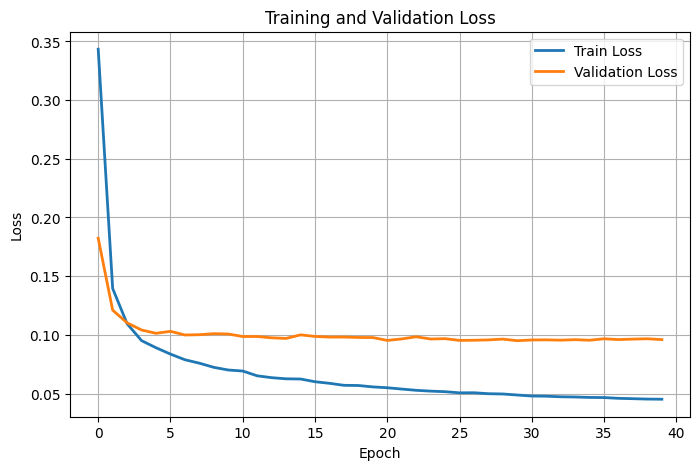

In [70]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

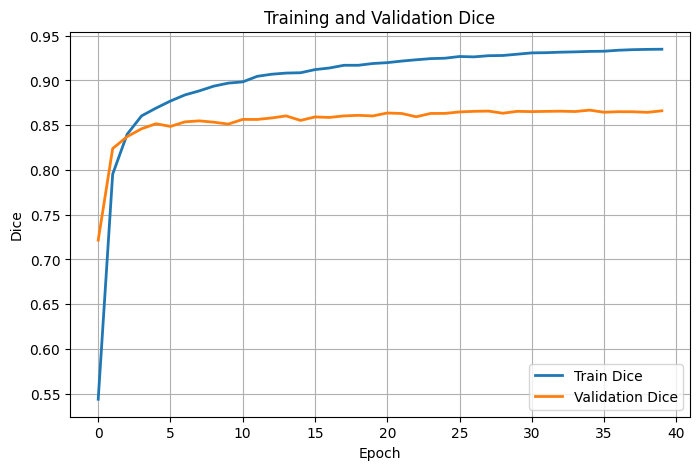

In [71]:
plt.figure(figsize=(8,5))

plt.plot(history["train_dice"], label="Train Dice", linewidth=2)
plt.plot(history["val_dice"], label="Validation Dice", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Training and Validation Dice")

plt.legend()
plt.grid(True)

plt.show()

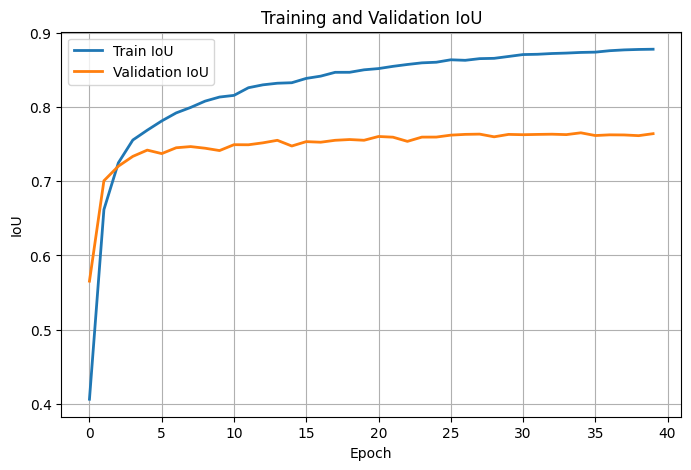

In [72]:
plt.figure(figsize=(8,5))

plt.plot(history["train_iou"], label="Train IoU", linewidth=2)
plt.plot(history["val_iou"], label="Validation IoU", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.title("Training and Validation IoU")

plt.legend()

plt.grid(True)

plt.show()

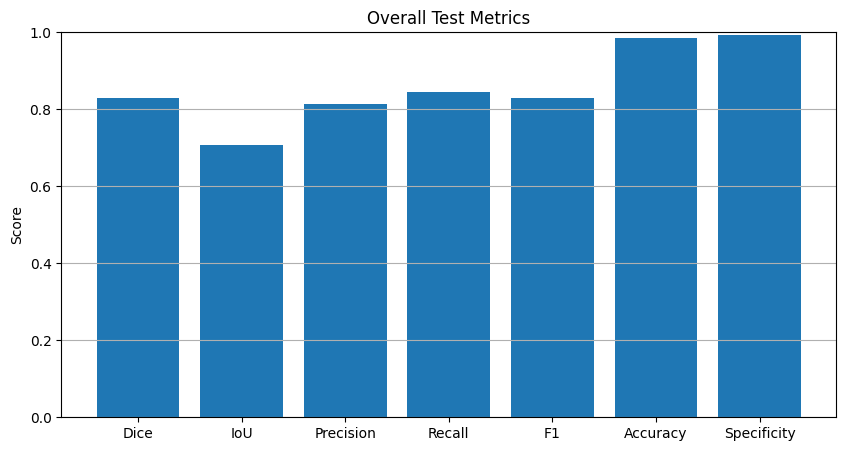

In [73]:
plt.figure(figsize=(10,5))

plt.bar(
    overall_results["Metric"],
    overall_results["Value"]
)

plt.ylim(0,1)

plt.title("Overall Test Metrics")

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()

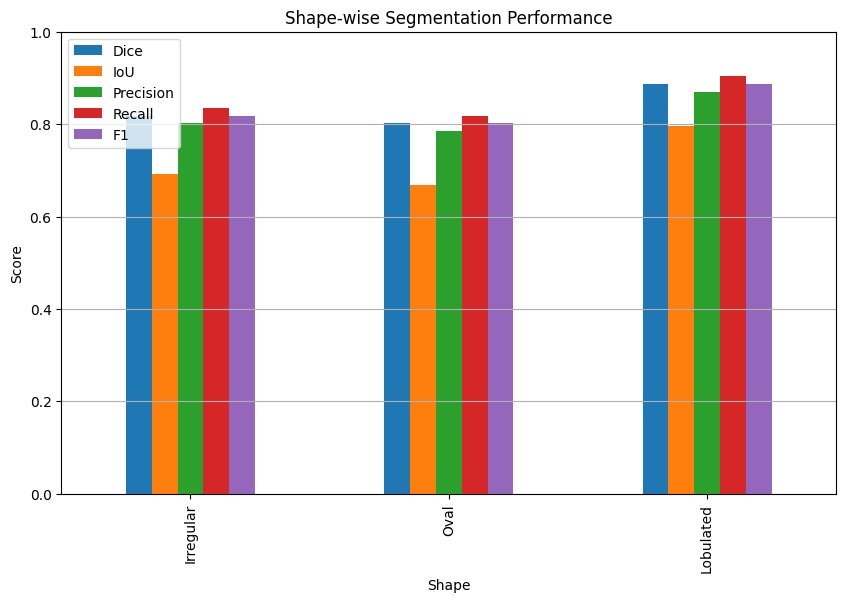

In [74]:
metrics = ["Dice","IoU","Precision","Recall","F1"]

shape_df.set_index("Shape")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Shape-wise Segmentation Performance")

plt.grid(axis="y")

plt.show()

In [75]:
def visualize_predictions(
    model,
    loader,
    device,
    num_images=5
):

    model.eval()

    with torch.no_grad():

        for images, masks, shapes in loader:

            images = images.to(device)

            outputs = model(images)

            preds = (
                torch.sigmoid(outputs) > 0.5
            ).float()

            for i in range(min(num_images, len(images))):

                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.imshow(
                    images[i,0].cpu(),
                    cmap="gray"
                )
                plt.title("Input")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(
                    masks[i,0],
                    cmap="gray"
                )
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(
                    preds[i,0].cpu(),
                    cmap="gray"
                )
                plt.title("Prediction")
                plt.axis("off")

                plt.show()

            break

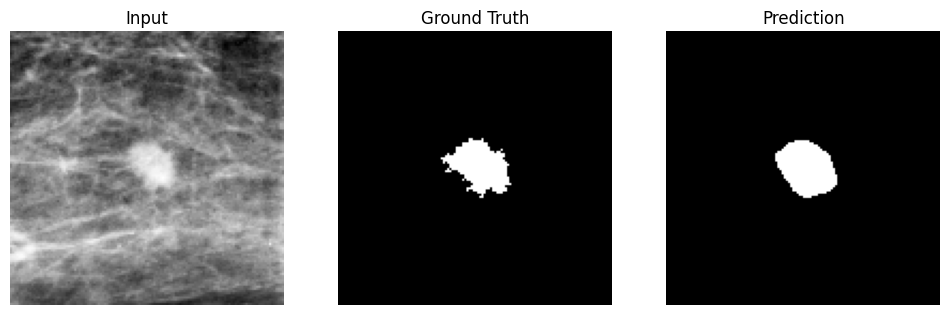

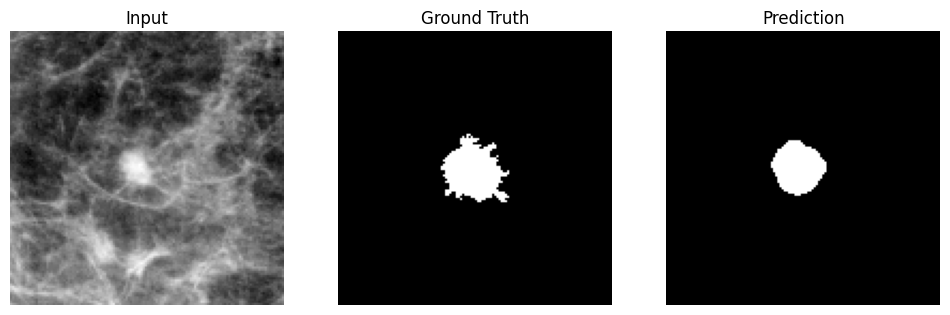

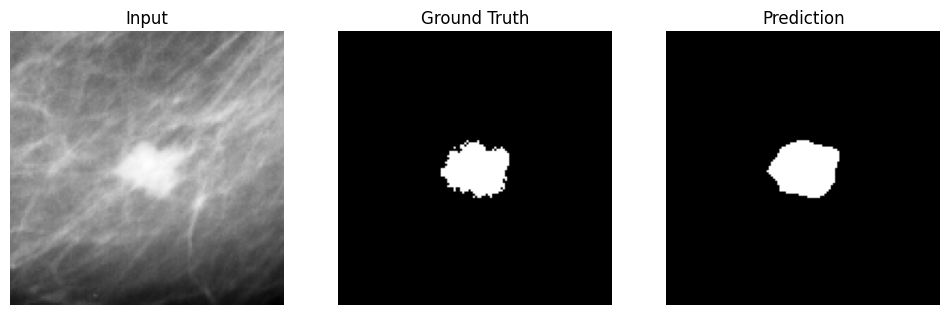

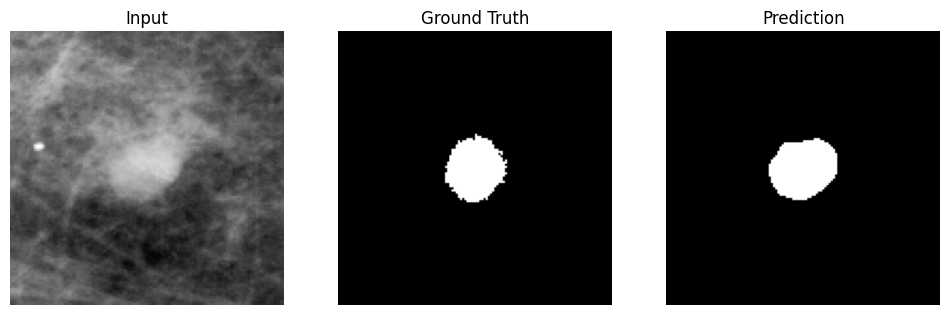

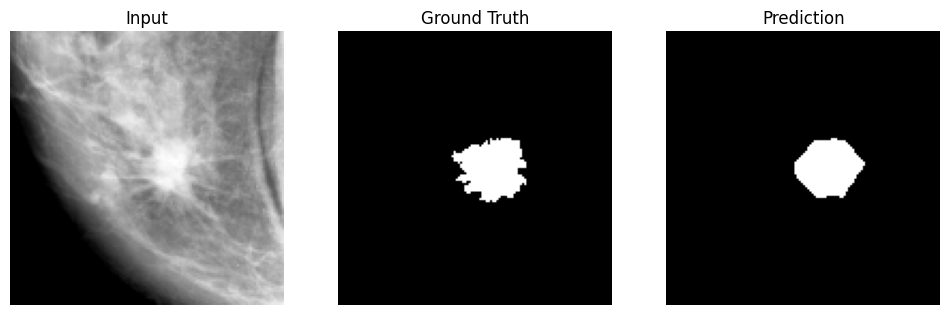

In [76]:
visualize_predictions(
    model,
    test_loader,
    device,
    num_images=5
)